# Linear Regression


C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)


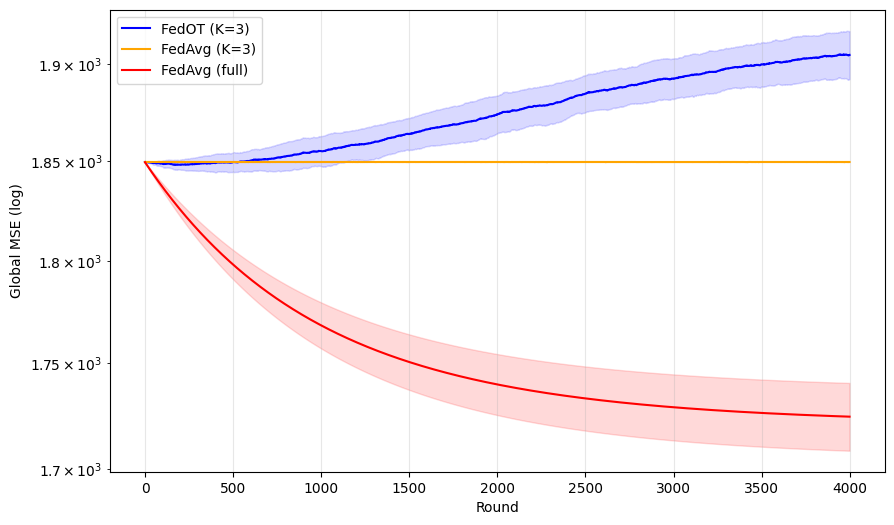

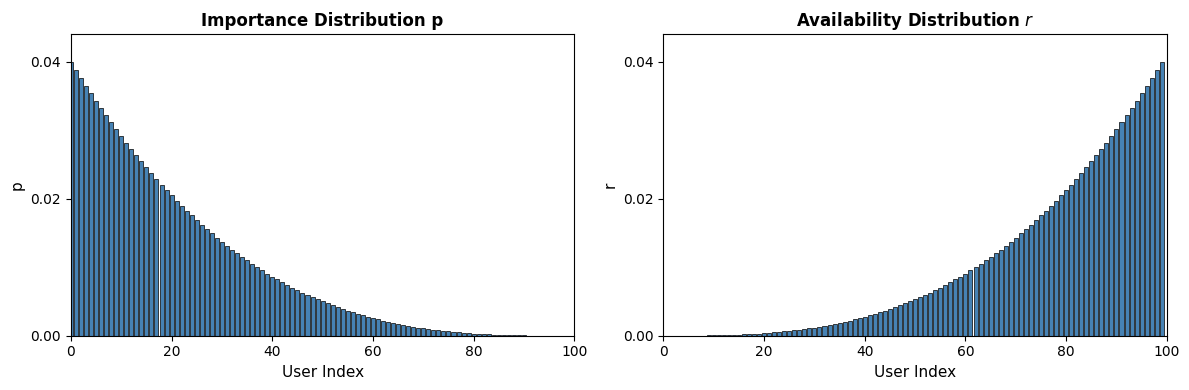

In [3]:
# ================================================================
# FedOT vs FedAvg on IMDb-Wiki (Linear Regression, Age Prediction)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.metrics import mean_squared_error

# ================================================================
# Config
# ================================================================
NUM_USERS = 100
K = 3
ROUNDS = 4000
LOCAL_EPOCHS = 5
DIM = 100
SAMPLES_PER_USER = 30
LR = 0.0001
SEEDS = [0, 1, 2, 3, 4]
NUM_SAMPLES_FOR_Q = 1_000_000

IPFP_TOL = 1e-12
IPFP_MAX_ITERS = 8000

# ================================================================
# Masked IPFP utilities
# ================================================================
def build_mask(n, subsets):
    M = np.zeros((n, len(subsets)), dtype=bool)
    for j, s in enumerate(subsets):
        for i in s:
            M[i-1, j] = True
    return M

def initialize_Y(p, q, M):
    Y = np.zeros_like(M, dtype=float)
    for j in range(M.shape[1]):
        rows = np.where(M[:, j])[0]
        if rows.size > 0:
            Y[rows, j] = q[j] / len(rows)
    return Y

def ipfp_masked(p, q, M, tol, max_iter):
    Y = initialize_Y(p, q, M)
    for _ in range(max_iter):
        Y *= (p / np.maximum(Y.sum(axis=1), 1e-12))[:, None]
        Y *= (q / np.maximum(Y.sum(axis=0), 1e-12))[None, :]
        if np.max(np.abs(Y.sum(axis=1) - p)) < tol:
            break
    return Y

def recover_T(Y, q, M):
    T = np.zeros_like(Y)
    for j in range(len(q)):
        if q[j] > 0:
            T[:, j] = Y[:, j] / q[j]
    T[~M] = 0
    T /= T.sum(axis=0, keepdims=True)
    return T

def solve_T(p, q, subsets):
    M = build_mask(len(p), subsets)
    Y = ipfp_masked(p, q, M, IPFP_TOL, IPFP_MAX_ITERS)
    return recover_T(Y, q, M)

def column_users_and_weights(T, subsets, j):
    rows = np.array([i-1 for i in subsets[j]])
    w = T[rows, j]
    w /= w.sum()
    return rows, w

# ================================================================
# Linear regression helpers
# ================================================================
def local_train(X, y, w, epochs):
    for _ in range(epochs):
        grad = X.T @ (X @ w - y) / len(y)
        w = w - LR * grad
    return w

def global_loss(w, user_data, p):
    return sum(p[i] * mean_squared_error(y, X @ w)
               for i, (X, y) in enumerate(user_data))

# ================================================================
# Distributions
# ================================================================
def make_skew_distributions(N):
    idx = np.arange(1, N+1)
    r = idx**3
    p = idx[::-1]**3
    return p/p.sum(), r/r.sum()

def all_K_subsets_1based(N, K):
    return list(combinations(range(1, N+1), K))

def estimate_q(subsets, r, N, K, samples, rng):
    counts = np.zeros(len(subsets))
    lookup = {s:i for i,s in enumerate(subsets)}
    for _ in range(samples):
        chosen = rng.choice(N, size=K, replace=False, p=r)
        tup = tuple(sorted(chosen+1))
        counts[lookup[tup]] += 1
    q = counts / counts.sum()
    return q

# ================================================================
# MAIN EXPERIMENT
# ================================================================
df = pd.read_csv("imdb_wiki.csv")
df = df[df["split"] == "train"]
df["client_id"] = df["path"].str.extract(r"(nm\d+)")

groups = [g for _, g in df.groupby("client_id") if len(g) >= SAMPLES_PER_USER]
groups = groups[:NUM_USERS]

p, r = make_skew_distributions(NUM_USERS)
subsets = all_K_subsets_1based(NUM_USERS, K)

all_fedot, all_faK, all_full = [], [], []

for seed in SEEDS:
    rng = np.random.RandomState(seed)

    # placeholder embeddings
    X_full = rng.randn(sum(len(g) for g in groups), DIM)
    y_full = np.concatenate([g["age"].values[:SAMPLES_PER_USER] for g in groups])

    user_data = []
    idx = 0
    for g in groups:
        user_data.append((X_full[idx:idx+SAMPLES_PER_USER],
                          y_full[idx:idx+SAMPLES_PER_USER]))
        idx += SAMPLES_PER_USER

    q = estimate_q(subsets, r, NUM_USERS, K, NUM_SAMPLES_FOR_Q, rng)
    q = (q + 1e-12) / np.sum(q)

    T = solve_T(p, q, subsets)
    q_cum = np.cumsum(q)

    w_ot = np.zeros(DIM)
    w_k  = np.zeros(DIM)
    w_f  = np.zeros(DIM)

    L_ot, L_k, L_f = [], [], []

    for _ in range(ROUNDS):
        j = np.searchsorted(q_cum, rng.rand())
        users, weights = column_users_and_weights(T, subsets, j)

        # FedOT
        models = [local_train(*user_data[u], w_ot.copy(), LOCAL_EPOCHS) for u in users]
        w_ot = sum(w*m for w, m in zip(weights, models))
        L_ot.append(global_loss(w_ot, user_data, p))

        # FedAvg(K)
        w_k = sum((NUM_USERS/K)*p[u]*local_train(*user_data[u], w_k.copy(), LOCAL_EPOCHS)
                  for u in users)
        L_k.append(global_loss(w_k, user_data, p))

        # FedAvg(full)
        w_f = sum(p[u]*local_train(*user_data[u], w_f.copy(), LOCAL_EPOCHS)
                  for u in range(NUM_USERS))
        L_f.append(global_loss(w_f, user_data, p))

    all_fedot.append(L_ot)
    all_faK.append(L_k)
    all_full.append(L_f)

# ================================================================
# Plot - Main Loss Curves
# ================================================================
def plot_curve(L, label, color):
    mean = np.mean(L, axis=0)
    std  = np.std(L, axis=0)
    x = np.arange(len(mean))
    plt.plot(x, mean, label=label, color=color)
    plt.fill_between(x, mean-std, mean+std, color=color, alpha=0.15)

plt.figure(figsize=(10,6))
plot_curve(all_fedot, "FedOT (K=" + str(K) + ")", "blue")
plot_curve(all_faK, "FedAvg (K=" + str(K) + ")", "orange")
plot_curve(all_full, "FedAvg (full)", "red")
plt.yscale("log")
plt.xlabel("Round")
plt.ylabel("Global MSE (log)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ================================================================
# Plot - Distributions
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Importance Distribution p
axes[0].bar(range(NUM_USERS), p, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title("Importance Distribution p", fontsize=12, fontweight='bold')
axes[0].set_xlabel("User Index", fontsize=11)
axes[0].set_ylabel("p", fontsize=11)
axes[0].set_xlim(0, 100)
axes[0].set_xticks([0, 20, 40, 60, 80, 100])
axes[0].set_ylim(0, max(p) * 1.1)
axes[0].set_yticks(np.linspace(0, max(p), 3))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

# Availability Distribution r
axes[1].bar(range(NUM_USERS), r, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title("Availability Distribution $r$", fontsize=12, fontweight='bold')
axes[1].set_xlabel("User Index", fontsize=11)
axes[1].set_ylabel("r", fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].set_xticks([0, 20, 40, 60, 80, 100])
axes[1].set_ylim(0, max(r) * 1.1)
axes[1].set_yticks(np.linspace(0, max(r), 3))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

plt.tight_layout()
plt.show()

# MNIST

C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)
C:\Users\goyski\AppData\Local\Temp\ipykernel_3452\1618290925.py:60: RuntimeWarning: invalid value encountered in divide
  T /= T.sum(axis=0, keepdims=True)


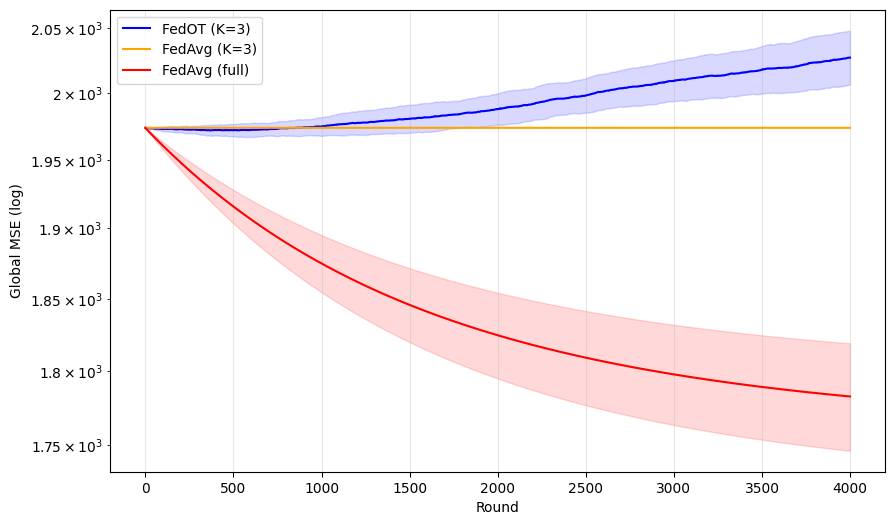

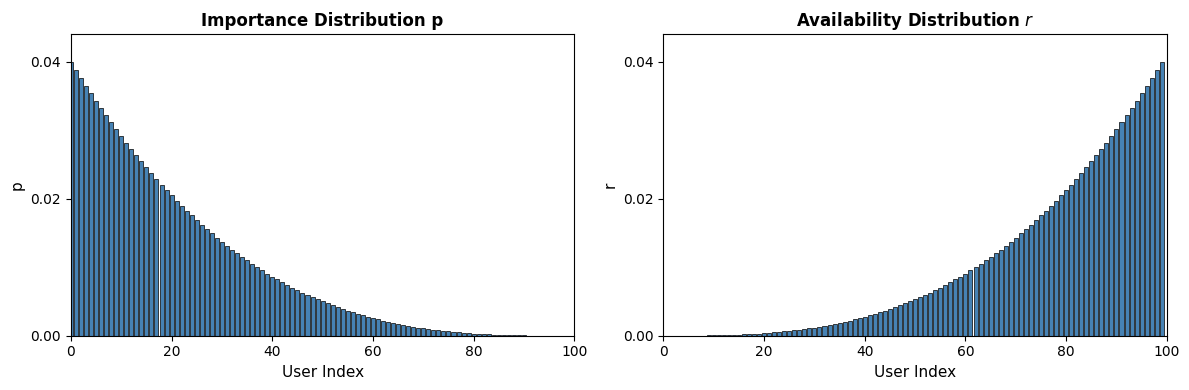

: 

In [ ]:
# ================================================================
# IMDb-Wiki (Age Regression) — Second Experiment Cell
# Same FedOT vs FedAvg logic, lighter config
# ================================================================

NUM_USERS = 100
K = 3
ROUNDS = 4000
LOCAL_EPOCHS = 3
DIM = 100
SAMPLES_PER_USER = 20
LR = 0.0001
SEEDS = [0,1,2,3,4]

p, r = make_skew_distributions(NUM_USERS)
subsets = all_K_subsets_1based(NUM_USERS, K)

df = pd.read_csv("imdb_wiki.csv")
df = df[df["split"] == "train"]
df["client_id"] = df["path"].str.extract(r"(nm\d+)")
groups = [g for _, g in df.groupby("client_id") if len(g) >= SAMPLES_PER_USER]
groups = groups[:NUM_USERS]

all_fedot, all_faK, all_full = [], [], []

for seed in SEEDS:
    rng = np.random.RandomState(seed)

    X_full = rng.randn(sum(len(g) for g in groups), DIM)
    y_full = np.concatenate([g["age"].values[:SAMPLES_PER_USER] for g in groups])

    user_data, idx = [], 0
    for g in groups:
        user_data.append((X_full[idx:idx+SAMPLES_PER_USER],
                          y_full[idx:idx+SAMPLES_PER_USER]))
        idx += SAMPLES_PER_USER

    q = estimate_q(subsets, r, NUM_USERS, K, 300_000, rng)
    q = (q + 1e-12) / np.sum(q)
    T = solve_T(p, q, subsets)
    q_cum = np.cumsum(q)

    w_ot = np.zeros(DIM)
    w_k  = np.zeros(DIM)
    w_f  = np.zeros(DIM)

    L_ot, L_k, L_f = [], [], []

    for _ in range(ROUNDS):
        j = np.searchsorted(q_cum, rng.rand())
        users, weights = column_users_and_weights(T, subsets, j)

        w_ot = sum(w*local_train(*user_data[u], w_ot.copy(), LOCAL_EPOCHS)
                   for w,u in zip(weights, users))
        L_ot.append(global_loss(w_ot, user_data, p))

        w_k = sum((NUM_USERS/K)*p[u]*local_train(*user_data[u], w_k.copy(), LOCAL_EPOCHS)
                  for u in users)
        L_k.append(global_loss(w_k, user_data, p))

        w_f = sum(p[u]*local_train(*user_data[u], w_f.copy(), LOCAL_EPOCHS)
                  for u in range(NUM_USERS))
        L_f.append(global_loss(w_f, user_data, p))

    all_fedot.append(L_ot)
    all_faK.append(L_k)
    all_full.append(L_f)

plt.figure(figsize=(10,6))
plot_curve(all_fedot, "FedOT (K=" + str(K) + ")", "blue") 
plot_curve(all_faK, "FedAvg (K=" + str(K) + ")", "orange")
plot_curve(all_full, "FedAvg (full)", "red")
plt.yscale("log")
plt.xlabel("Round")
plt.ylabel("Global MSE (log)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ================================================================
# Plot - Distributions
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Importance Distribution p
axes[0].bar(range(NUM_USERS), p, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title("Importance Distribution p", fontsize=12, fontweight='bold')
axes[0].set_xlabel("User Index", fontsize=11)
axes[0].set_ylabel("p", fontsize=11)
axes[0].set_xlim(0, 100)
axes[0].set_xticks([0, 20, 40, 60, 80, 100])
axes[0].set_ylim(0, max(p) * 1.1)
axes[0].set_yticks(np.linspace(0, max(p), 3))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

# Availability Distribution r
axes[1].bar(range(NUM_USERS), r, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title("Availability Distribution $r$", fontsize=12, fontweight='bold')
axes[1].set_xlabel("User Index", fontsize=11)
axes[1].set_ylabel("r", fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].set_xticks([0, 20, 40, 60, 80, 100])
axes[1].set_ylim(0, max(r) * 1.1)
axes[1].set_yticks(np.linspace(0, max(r), 3))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

plt.tight_layout()
plt.show()
